
==== Naive Bayes ====
              precision    recall  f1-score   support

           0       0.90      0.27      0.42     16407
           1       0.88      0.99      0.93     88756

    accuracy                           0.88    105163
   macro avg       0.89      0.63      0.67    105163
weighted avg       0.88      0.88      0.85    105163

ROC AUC: 0.9368


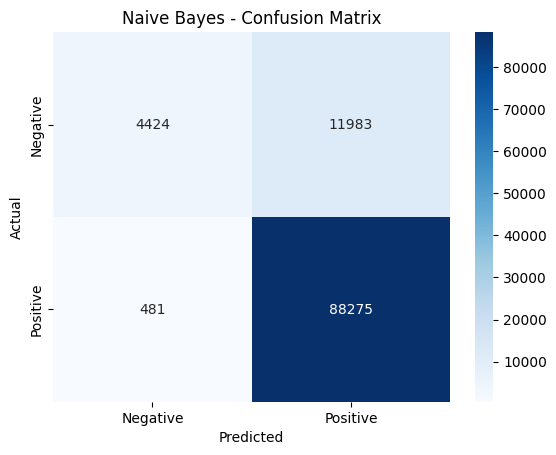


==== Logistic Regression ====
              precision    recall  f1-score   support

           0       0.84      0.67      0.74     16407
           1       0.94      0.98      0.96     88756

    accuracy                           0.93    105163
   macro avg       0.89      0.82      0.85    105163
weighted avg       0.92      0.93      0.92    105163

ROC AUC: 0.9565


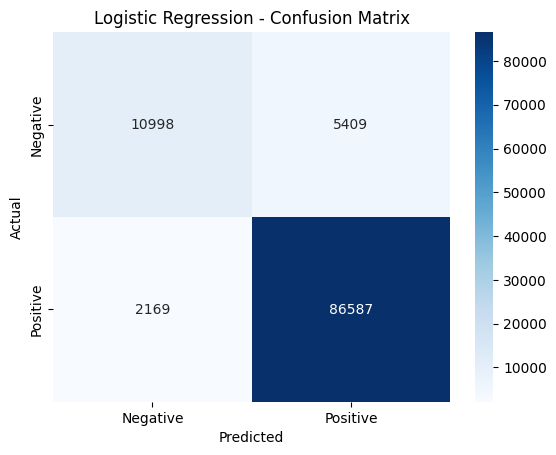

In [1]:
# 1. 경로 설정 및 모듈 import
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from src.preprocessing import preprocess_dataframe
from src.model import train_model, save_model
from src.evaluation import evaluate_model

# 2. 데이터 로드 및 전처리
df = pd.read_csv('../data/Reviews.csv')
df = preprocess_dataframe(df)
X, y = df['Text'], df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. 벡터화
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,1), stop_words='english')
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

# 저장 (선택)
joblib.dump(tfidf, '../outputs/vectorizer_nb.pkl')

# 4a. Naive Bayes
nb = train_model(X_train_vec, y_train, model_type='nb')
save_model(nb, '../outputs/models/naive_bayes.pkl')   # ← 🔥 이 줄 추가
evaluate_model("Naive Bayes", nb, X_test_vec, y_test)

# 4b. Logistic Regression
lr = train_model(X_train_vec, y_train, model_type='logistic')
save_model(lr, '../outputs/models/logistic.pkl')
evaluate_model("Logistic Regression", lr, X_test_vec, y_test)



==== Naive Bayes ====
              precision    recall  f1-score   support

           0       0.90      0.27      0.42     16407
           1       0.88      0.99      0.93     88756

    accuracy                           0.88    105163
   macro avg       0.89      0.63      0.68    105163
weighted avg       0.88      0.88      0.85    105163

ROC AUC: 0.9374


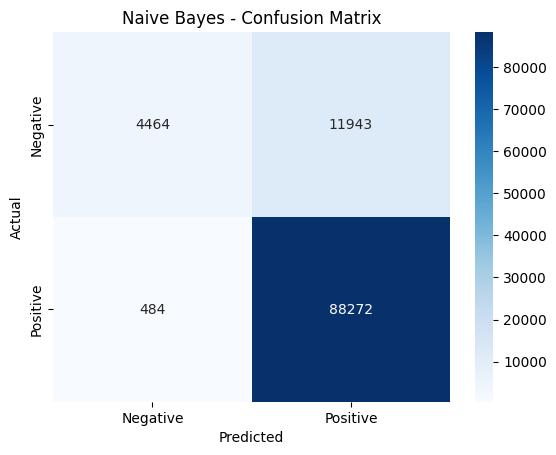


==== Logistic Regression + Balanced ====
              precision    recall  f1-score   support

           0       0.62      0.89      0.73     16407
           1       0.98      0.90      0.94     88756

    accuracy                           0.90    105163
   macro avg       0.80      0.90      0.83    105163
weighted avg       0.92      0.90      0.90    105163

ROC AUC: 0.9586


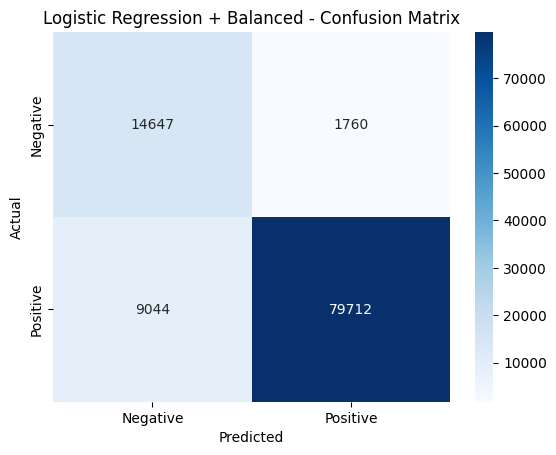

In [2]:
# 1. 라이브러리 + 경로 설정
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from src.model import train_model, save_model
from src.evaluation import evaluate_model

# 2. 데이터 로드
df = pd.read_csv('../data/preprocessed.csv')
X, y = df['Text'], df['Sentiment']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. 벡터화
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,1), stop_words='english')
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

# 저장 (선택)
joblib.dump(tfidf, '../outputs/vectorizer_logistic.pkl')

# 4a. Naive Bayes 학습 + 평가
nb = train_model(X_train_vec, y_train, model_type='nb')
evaluate_model("Naive Bayes", nb, X_test_vec, y_test)

# 4b. Logistic Regression + balanced
lr = train_model(X_train_vec, y_train, model_type='logistic', class_weight='balanced')
save_model(lr, '../outputs/models/logistic_balanced.pkl')
evaluate_model("Logistic Regression + Balanced", lr, X_test_vec, y_test)
